🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Weekly pipeline** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [05b Suggest Engine v2](05_suggest_engine_v2.ipynb) → [07 Ceiling Estimator](07_ceiling_estimator.ipynb) → **08 Anti-Hallucination Check** → *submit*

---

# 08 · Anti-Hallucination Check
### A last look at the human decision before it goes to the portal

This notebook does not choose a query. It reads the query **you have already decided on** — the
newest `week*_engine_submission.txt` in this directory — and asks one question about each of the
eight vectors:

> *How much of the case for this probe is carried by the data, and how much by a model
> asserting things the data does not say?*

That second quantity is what this campaign has been calling a hallucination since notebook 07
described naive GP-UCB as something that "hallucinates headroom exactly where the pathology-aware
estimators say the game is over". Here it is measured rather than described.

---

## What it is, and what it is not

**It is** a critic. It scores seven independent axes, prints the evidence behind every number, and
hands you a paragraph per function. Disagreeing with it is a legitimate outcome — some of the best
probes in this campaign would score badly here, and the notebook says so out loud.

**It is not** an oracle. It cannot see the true functions. It inherits 05b's pathology labels, so it
inherits 05b's mistakes. Its calibration axis rests on nine walk-forward weeks per function, which is
a small sample by any standard. It is a **beta**: read the critique, not the number.

**Risk is not badness.** A probe the surrogate expects to lose is often exactly the right purchase —
information now, score later. Facts of that kind are reported as **decision flags** and deliberately
kept *out* of the risk score, so that buying information is never punished as if it were an error.

## The seven axes

| axis | question | what a high score means |
|---|---|---|
| **A · support** | how far is this point from the evidence? | the prediction here is a prior wearing a posterior's clothes |
| **B · model agreement** | do six different surrogates agree? | the number the engine acted on is a property of the kernel |
| **C · calibration** | has this function's error bar been honest? | its intervals have been too narrow before, walk-forward |
| **D · headroom** | is the implied gain compatible with any ceiling? | headroom is being invented, or spent headroom is being re-sold |
| **E · stability** | how old is the strategy that produced this? | the module was re-chosen by the last data point |
| **F · resolvability** | can this probe resolve its own claim? | the claimed gain is below the noise floor |
| **G · rationale** | does the written justification survive contact with the data? | stated claims are contradicted by the observations |

Axis G is optional and off unless you paste text into `RATIONALES`. It is the crudest of the seven:
it only recognises claim shapes it was taught, and **silence from it means "nothing recognised",
never "nothing wrong"**.

## Running it

Put this notebook beside `consolidated_observations.csv` and your submission file. It selects the
**highest-numbered** `week*_engine_submission.txt` automatically, so dropping in
`week11_engine_submission.txt` is the only step needed next week. `05_suggest_engine_v2.ipynb` and
`ceiling_estimates.csv` are used if present and skipped cleanly if not.

## 0 · Configuration, data, and the submission under audit

In [1]:
import warnings, re, glob, os, json
import numpy as np, pandas as pd
from scipy.stats import norm, spearmanr
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------- configuration
DATA_DIR      = "."                                  # where the CSV + submissions live
CONSOLIDATED  = os.path.join(DATA_DIR, "consolidated_observations.csv")
SUBMISSION_GLOB = os.path.join(DATA_DIR, "week*_engine_submission.txt")
CEILING_CSV   = os.path.join(DATA_DIR, "ceiling_estimates.csv")   # optional (from nb 07)
SEED          = 42
LOCK_PRIOR    = (7, 8)        # analytic identities (human prior, carried over from 05b/07)
NOISE_BREACH_Z = 2.0          # |z| beyond this counts as a predictive breach in the backtest

# Optional: paste the human/LLM justification for each function here. Empty = skip Axis G.
RATIONALES = {}

# ---------------------------------------------------------------- load observations
OBS   = pd.read_csv(CONSOLIDATED)
DIMS  = OBS.groupby("function").dim.first().to_dict()
FIDS  = sorted(DIMS)
N_WEEKS = int(OBS.week.max())
TARGET_WEEK = N_WEEKS + 1


def xy(fid, df=None):
    """Design matrix, response and raw rows for one function."""
    df = OBS if df is None else df
    sub = df[df.function == fid]
    d = DIMS[fid]
    return (sub[[f"x{i+1}" for i in range(d)]].to_numpy(float),
            sub["y"].to_numpy(float), sub)


# ---------------------------------------------------------------- find the submission
def latest_submission(pattern=SUBMISSION_GLOB):
    """Newest week*_engine_submission.txt by week index, not by mtime."""
    found = []
    for p in glob.glob(pattern):
        m = re.search(r"week(\d+)_engine_submission\.txt$", os.path.basename(p))
        if m:
            found.append((int(m.group(1)), p))
    if not found:
        raise FileNotFoundError(f"no submission file matching {pattern}")
    found.sort()
    return found[-1][1], found[-1][0], [p for _, p in sorted(found)]


def parse_submission(path):
    """'a-b|c-d|...' -> {fid: np.array}. Tolerates whitespace and a trailing newline."""
    # utf-8-sig, not the platform default: on Windows open() falls back to cp1252, and
    # -sig also absorbs a BOM if the file has ever been through Notepad.
    raw = open(path, encoding="utf-8-sig").read().strip()
    groups = [g.strip() for g in raw.split("|") if g.strip()]
    out = {}
    for i, g in enumerate(groups, start=1):
        out[i] = np.array([float(v) for v in g.split("-") if v != ""], float)
    return out, raw


SUB_PATH, SUB_WEEK, ALL_SUBS = latest_submission()
QUERY, SUB_RAW = parse_submission(SUB_PATH)


# ---------------------------------------------------------------- Gate 0: structure
def structural_gate(query, sub_week):
    rows, fatal = [], False
    seen = set(query) | set(FIDS)
    for f in sorted(seen):
        x = query.get(f)
        issues = []
        if x is None:
            issues.append("MISSING from submission")
        else:
            d = DIMS.get(f)
            if d is None:
                issues.append("function not present in observations")
            elif len(x) != d:
                issues.append(f"arity {len(x)} != expected {d}")
            if np.any(~np.isfinite(x)):
                issues.append("non-finite value")
            if np.any(x < 0) or np.any(x > 1):
                bad = np.where((x < 0) | (x > 1))[0] + 1
                issues.append("out of [0,1] at x" + ",x".join(map(str, bad)))
            if d is not None and len(x) == d:
                X, _, _ = xy(f)
                past = {tuple(np.round(p, 6)) for p in X}
                if tuple(np.round(x, 6)) in past:
                    issues.append("EXACT REPEAT of a past query at 6 dp")
        if any("arity" in i or "MISSING" in i or "out of" in i or "non-finite" in i
               for i in issues):
            fatal = True
        rows.append({"F": f"F{f}", "dim expected": DIMS.get(f),
                     "dim given": None if x is None else len(x),
                     "structural issues": "; ".join(issues) or "ok"})
    gate = pd.DataFrame(rows)
    return gate, fatal


# ---------------------------------------------------------------- shared machinery
def noise_sd(fid, df=None):
    """Observation noise. Prefers near-exact resamples; falls back to a GP WhiteKernel."""
    X, y, _ = xy(fid, df)
    pairs = [abs(y[i] - y[j])
             for i in range(len(X)) for j in range(i + 1, len(X))
             if np.linalg.norm(X[i] - X[j]) < 0.01]
    if pairs:
        return float(np.median(pairs) / np.sqrt(2)), "near-exact resamples"
    k = C(1.0) * Matern(0.2, nu=2.5) + WhiteKernel(1e-3, (1e-12, 1e2))
    gp = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=2,
                                  random_state=SEED).fit(X, y)
    return float(np.sqrt(gp.kernel_.k2.noise_level) * np.std(y)), "GP WhiteKernel"


def y_transform(fid, y):
    """Work in log space when the response spans many decades and is positive.

    F5 spans ~5 decades; comparing model spread on the raw scale there would drown
    every other function's signal. Returns (yt, name).
    """
    pos = y > 0
    if pos.all() and y.max() / max(y.min(), 1e-300) > 1e3:
        return np.log(y), "log"
    return y.copy(), "identity"


def referee_gp(fid, df=None, log=None):
    """The same noise-aware Matern referee used by 05b, so the audit prices the
    query on the engine's own terms rather than a private model of our own."""
    X, y, _ = xy(fid, df)
    yt, tname = y_transform(fid, y) if log is None else (
        (np.log(y), "log") if log else (y.copy(), "identity"))
    k = (C(1.0) * Matern(0.2, nu=2.5, length_scale_bounds=(0.02, 2.0))
         + WhiteKernel(1e-4, (1e-12, 1e2)))
    gp = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=3,
                                  random_state=SEED).fit(X, yt)
    return gp, yt, tname

In [2]:
print(f"observations : {len(OBS)} rows · functions {FIDS} · weeks 0-{N_WEEKS}")
print(f"submission    : {os.path.basename(SUB_PATH)}  (week {SUB_WEEK})")
if len(ALL_SUBS) > 1:
    print(f"                selected as newest of {[os.path.basename(p) for p in ALL_SUBS]}")
print(f"auditing for  : week {TARGET_WEEK}")
if SUB_WEEK != TARGET_WEEK:
    print(f"\n  !! the newest submission is week {SUB_WEEK} but the data runs to week {N_WEEKS}.")
    print(f"     Either the results for week {SUB_WEEK} are already in the CSV (in which case this")
    print(f"     is a post-mortem, not a pre-submission check), or a file is missing.")
for f in FIDS:
    print(f"  F{f}: " + "-".join(f"{v:.6f}" for v in QUERY[f]))

observations : 279 rows · functions [1, 2, 3, 4, 5, 6, 7, 8] · weeks 0-13
submission    : week14_engine_submission.txt  (week 14)
                selected as newest of ['week8_engine_submission.txt', 'week9_engine_submission.txt', 'week10_engine_submission.txt', 'week11_engine_submission.txt', 'week12_engine_submission.txt', 'week13_engine_submission.txt', 'week14_engine_submission.txt']
auditing for  : week 14
  F1: 0.644156-0.601884
  F2: 0.785400-0.232500
  F3: 0.306054-0.540484-0.529115
  F4: 0.439084-0.421578-0.306838-0.465977
  F5: 1.000000-1.000000-1.000000-0.800000
  F6: 0.246126-0.321303-0.612008-0.717899-0.000000
  F7: 0.201689-0.150011-0.476874-0.275333-0.311652-0.657301
  F8: 0.100000-0.150000-0.130000-0.150000-0.800000-0.500001-0.200000-0.600000


## 1 · Gate 0 — structure before substance

Nothing downstream means anything if the file is malformed. Arity against `DIMS`, bounds, finiteness,
and a collision check at the portal's 6-decimal resolution — the automated version of the trailing-digit
catch that saved the week-7 F8 probe.

An exact repeat is reported but **not** treated as fatal: on a solved function it is the whole point of
an ε-lock, and Axis F tells the two cases apart later.

In [3]:
GATE, FATAL = structural_gate(QUERY, SUB_WEEK)
display(GATE)
print("FATAL — fix the submission before reading anything below." if FATAL
      else "Structure is sound; proceeding to the substantive axes.")

,F,dim expected,dim given,structural issues
0,F1,2,2,ok
1,F2,2,2,ok
2,F3,3,3,ok
3,F4,4,4,ok
4,F5,4,4,ok
5,F6,5,5,ok
6,F7,6,6,ok
7,F8,8,8,ok


Structure is sound; proceeding to the substantive axes.


## 2 · The pathology router, ported from 05b

The audit has to judge the label the engine **acted on**, not a private opinion of its own, so this is
05b's classifier carried over unchanged. Keeping a copy rather than importing is a deliberate trade: it
survives 05b being edited mid-week, at the cost of needing to be re-synced when 05b's rules change.

Axis E falls straight out of it — re-label the function using only the data available at each past week
and watch whether the label holds still.

In [4]:
# --------------------------------------------------------------- pathology router
# Ported verbatim in behaviour from 05b so that the audit judges the *same* label the
# engine acted on. If 05b's classifier changes, change it here too, or the audit will
# be critiquing a strategy nobody used.

def sig_needle(y):
    ay = np.abs(y); eps = 1e-300
    decades = float(np.log10(ay.max() + eps) - np.log10(np.median(ay) + eps))
    background = float(np.mean(ay < 0.01 * ay.max()))
    return decades, background


def weekly_trace(fid, df=None):
    _, _, sub = xy(fid, df)
    wk = sub[sub.week > 0].sort_values("week")
    return wk[[f"x{i+1}" for i in range(DIMS[fid])]].to_numpy(float), wk["y"].to_numpy(float)


def classify(fid, df=None):
    """Priority: lock > needle > boundary_climb > stochastic_capped > local_peak
    (fresh gradient) > plateau > local_peak (default)."""
    if fid in LOCK_PRIOR:
        return "solved_lock", ["analytic identity confirmed (human prior); optimum banked"]
    X, y, sub = xy(fid, df); d = DIMS[fid]
    Xw, yw = weekly_trace(fid, df)

    decades, bg = sig_needle(y)
    if decades >= 6 and bg >= 0.5:
        return "needle", [f"magnitude cascade {decades:.0f} decades; {bg:.0%} background"]

    i_best = int(np.argmax(y)); best_week = int(sub.iloc[i_best]["week"])
    at_bound = int(np.sum((X[i_best] < .03) | (X[i_best] > .97)))
    rhos = [abs(spearmanr(X[:, j], y)[0] or 0) for j in range(d)]
    if at_bound >= d - 1 and np.mean(rhos) > .4 and y.max() > 10 * abs(np.median(y)):
        return "boundary_climb", [f"{at_bound}/{d} coords at bounds; "
                                  f"mean |rho|={np.mean(rhos):.2f}; huge monotone range"]

    nsd, src = noise_sd(fid, df)
    if nsd > 0 and best_week <= 1:
        near = [yy for xx, yy in zip(X, y)
                if np.linalg.norm(xx - X[i_best]) < 0.08 and yy < y.max()]
        if len(near) >= 2 and max(near) < y.max() and np.mean(near) < y.max() - nsd:
            return "stochastic_capped", [f"best {y.max():.4g} is a week-{best_week} draw; "
                                         f"{len(near)} nearby re-reads never re-attained it"]

    if len(yw) >= 2:
        prev_best = np.max(sub[sub.week < sub.week.max()].y.values)
        step = np.linalg.norm(Xw[-1] - Xw[-2])
        if yw[-1] >= prev_best - 1e-12 and step < 0.25:
            return "local_peak", [f"new best-ever last week (+{yw[-1]-prev_best:.3g}) "
                                  f"via a {step:.3f}-norm step"]
        weeks_since = int(sub.week.max() - best_week)
        if weeks_since >= 3:
            return "plateau", [f"no new best for {weeks_since} weeks"]
    return "local_peak", ["default: learnable, not stalled"]


# ----------------------------------------------------- Axis E: label stability
def label_history(fid, lo=2, hi=None):
    """Re-label the function using only data through each past week."""
    hi = N_WEEKS if hi is None else hi
    out = {}
    for w in range(lo, hi + 1):
        try:
            out[w] = classify(fid, OBS[OBS.week <= w])[0]
        except Exception as e:
            out[w] = f"err:{type(e).__name__}"
    return out


def axis_label_stability(fid, window=4):
    """A strategy that changes identity every time one point lands is not a strategy.

    Score rises with the number of label flips in the recent window: the pick inherits
    the fragility of the module that produced it.
    """
    hist = label_history(fid)
    weeks = sorted(hist)
    recent = [hist[w] for w in weeks if w > N_WEEKS - window]
    flips_recent = sum(1 for a, b in zip(recent, recent[1:]) if a != b)
    flips_all = sum(1 for a, b in zip([hist[w] for w in weeks],
                                      [hist[w] for w in weeks][1:]) if a != b)
    flipped_last = len(recent) >= 2 and recent[-1] != recent[-2]
    score = min(1.0, 0.45 * flips_recent + 0.15 * max(0, flips_all - flips_recent))
    detail = " -> ".join(f"w{w}:{hist[w]}" for w in weeks[-window:])
    note = (f"label changed at the most recent week ({recent[-2]} -> {recent[-1]}); "
            f"the strategy module that generated this pick is {flips_recent} flips old"
            if flipped_last else
            f"{flips_recent} flip(s) in the last {window} weeks")
    return score, note, detail, hist

## 3 · Axes A, B, D, F

**A · support** asks three things: distance to the nearest observation in units of the design's own
typical spacing, how many points lie within the fitted length scale, and — for picks that move
essentially one coordinate — whether the query sits inside an *unsampled gap* along that coordinate.
The gap test earns its place on F5, where the on-line evidence along x1 is `{0, 0.015, 0.03, 1.0}` and
any query near 0.75 is a smooth line drawn across a hole. It is switched off for trust-region clouds in
4-D and above, where demanding on-line neighbours would flag everything.

**B · model agreement** fits six surrogates with genuinely different inductive biases — three GPs, a
quadratic, a forest, and a 3-NN — and measures their scatter at the query. Where the data pins the
answer down they agree. It also reports scatter relative to the referee's *own* error bar, which is the
overconfidence the campaign kept running into.

**D · headroom** builds a ceiling deliberately **not** taken from notebook 07 — an audit that reuses the
estimator it audits cannot catch that estimator being wrong — and additionally walks the ceiling forward
through history to count how often it has been broken by the next week's probe.

**F · resolvability** separates *wrong* from *pointless*, and pointless-by-accident from
pointless-on-purpose.

In [5]:
# ---------------------------------------------------------- helpers shared by axes
def _noise_from(X, y):
    """Noise sd on whatever scale y is given in (raw or log)."""
    pairs = [abs(y[i] - y[j])
             for i in range(len(X)) for j in range(i + 1, len(X))
             if np.linalg.norm(X[i] - X[j]) < 0.01]
    if pairs:
        return float(np.median(pairs) / np.sqrt(2))
    return float(0.02 * (np.std(y) or 1.0))


def _nn_scale(X):
    """Median nearest-neighbour distance: the natural 'one step' for this design."""
    if len(X) < 2:
        return 1.0
    D = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
    np.fill_diagonal(D, np.inf)
    return float(np.median(D.min(axis=1)))



def _online_gap(X, xq, j, tol=0.02):
    """Evidence along one axis, holding the others fixed.

    A GP will happily draw a smooth line across a gap containing no observations.
    This measures how wide that gap is and how deep inside it the query sits.
    """
    others = [k for k in range(len(xq)) if k != j]
    m = np.all(np.abs(X[:, others] - xq[others]) < tol, axis=1) if others else np.ones(len(X), bool)
    v = np.sort(X[m, j])
    out = dict(n=int(m.sum()), vals=v, gap=np.nan, span=np.nan,
               interior=np.nan, beyond=np.nan)
    if len(v) < 2:
        return out
    out["span"] = float(v[-1] - v[0])
    lo, hi = v[v <= xq[j]], v[v >= xq[j]]
    if len(lo) == 0 or len(hi) == 0:
        out["beyond"] = float(min(abs(xq[j] - v[0]), abs(xq[j] - v[-1])))
    else:
        a, b = float(lo.max()), float(hi.min())
        out["gap"] = b - a
        out["interior"] = (2 * min(xq[j] - a, b - xq[j]) / out["gap"]) if out["gap"] > 1e-12 else 0.0
    return out


# ------------------------------------------------- Axis A: is the query supported?
def axis_support(fid, xq, df=None):
    """Distance from the query to the evidence.

    A prediction at a point with no neighbours is not a prediction, it is a prior.
    """
    X, y, _ = xy(fid, df)
    gp, yt, _ = referee_gp(fid, df)
    try:
        ls = float(np.ravel(gp.kernel_.k1.k2.length_scale)[0])
    except Exception:
        ls = 0.2
    d = np.linalg.norm(X - xq, axis=1)
    d1 = float(d.min())
    nn = _nn_scale(X)
    ratio = d1 / max(nn, 1e-9)
    n_local = int(np.sum(d <= ls))

    lo, hi = X.min(axis=0), X.max(axis=0)
    outside = [j + 1 for j in range(len(xq)) if xq[j] < lo[j] - 1e-12 or xq[j] > hi[j] + 1e-12]

    # "On-line" evidence: observations agreeing with the query on all but one coordinate.
    # This is the evidence a coordinate-scan candidate actually rests on.
    online = {}
    for j in range(len(xq)):
        others = [k for k in range(len(xq)) if k != j]
        m = np.all(np.abs(X[:, others] - xq[others]) < 0.02, axis=1) if others else np.ones(len(X), bool)
        online[j + 1] = int(m.sum())
    j_far = int(np.argmax(np.abs(xq - X[np.argmax(y)]))) + 1 if len(X) else 1
    online_on_moved_axis = online.get(j_far, 0)

    # The on-line gap test only means something for a pick that moves essentially one
    # coordinate. For a trust-region cloud in 5-D it would fire on everything, so there
    # we fall back to local density and say nothing about gaps.
    inc = X[np.argmax(y)]
    n_moved = int(np.sum(np.abs(xq - inc) > 0.02))
    axis_aligned = n_moved <= 1
    gapinfo = _online_gap(X, xq, j_far - 1) if axis_aligned else dict(
        n=0, vals=np.array([]), gap=np.nan, span=np.nan, interior=np.nan, beyond=np.nan)
    scale = max(gapinfo["span"] if np.isfinite(gapinfo["span"]) else 0.0, nn)
    if not axis_aligned:
        s_gap = float(np.exp(-n_local / 2.0))
    elif np.isfinite(gapinfo.get("gap", np.nan)):
        s_gap = float(np.clip(gapinfo["interior"], 0, 1) *
                      np.clip(gapinfo["gap"] / max(3 * nn, 1e-9), 0, 1))
    elif np.isfinite(gapinfo.get("beyond", np.nan)):
        s_gap = float(np.clip(gapinfo["beyond"] / max(scale, 1e-9), 0, 1))
    else:
        s_gap = 0.6

    s_dist = 1.0 - np.exp(-max(0.0, ratio - 1.0))
    s_local = float(np.exp(-n_local / 2.0))
    score = float(np.clip(0.35 * s_dist + 0.30 * s_local + 0.35 * s_gap, 0, 1))
    if outside:
        score = min(1.0, score + 0.25)

    notes = []
    if n_local == 0:
        notes.append(f"no observation within the fitted length scale ({ls:.3f}) of this point")
    if ratio > 2:
        notes.append(f"nearest observation is {ratio:.1f}x the typical inter-point spacing away")
    if outside:
        notes.append("outside the observed range on x" + ", x".join(map(str, outside)))
    if axis_aligned and online_on_moved_axis <= 2:
        notes.append(f"only {online_on_moved_axis} on-line point(s) along x{j_far}, "
                     f"the axis this pick moves most — the shape there is assumed, not measured")
    if np.isfinite(gapinfo.get("gap", np.nan)) and s_gap > 0.3:
        notes.append(f"sits inside an unsampled gap of width {gapinfo['gap']:.3f} along x{j_far} "
                     f"(on-line values {np.round(gapinfo['vals'], 3).tolist()}) — the value here is "
                     f"interpolation, and the gap is {gapinfo['gap']/max(nn,1e-9):.1f}x the typical spacing")
    elif np.isfinite(gapinfo.get("beyond", np.nan)) and s_gap > 0.3:
        notes.append(f"lies {gapinfo['beyond']:.4f} beyond the on-line range along x{j_far} — "
                     f"extrapolation, not interpolation")
    return dict(score=score, d1=d1, nn=nn, ratio=ratio, n_local=n_local, ls=ls,
                s_dist=s_dist, s_local=s_local, s_gap=s_gap, gap=gapinfo,
                outside=outside, online=online, moved_axis=j_far,
                axis_aligned=axis_aligned, n_moved=n_moved,
                online_moved=online_on_moved_axis,
                note="; ".join(notes) or "query sits inside well-sampled territory")


# ------------------------------------- Axis B: do independent models agree here?
def _ensemble(X, yt, seed=SEED):
    ms = {}
    ms["GP Matern2.5"] = GaussianProcessRegressor(
        C(1.0) * Matern(0.2, nu=2.5, length_scale_bounds=(0.02, 2.0)) + WhiteKernel(1e-4, (1e-12, 1e2)),
        normalize_y=True, n_restarts_optimizer=2, random_state=seed)
    ms["GP Matern1.5"] = GaussianProcessRegressor(
        C(1.0) * Matern(0.5, nu=1.5, length_scale_bounds=(0.05, 5.0)) + WhiteKernel(1e-4, (1e-12, 1e2)),
        normalize_y=True, n_restarts_optimizer=2, random_state=seed + 1)
    ms["GP RBF"] = GaussianProcessRegressor(
        C(1.0) * RBF(0.3, length_scale_bounds=(0.05, 5.0)) + WhiteKernel(1e-4, (1e-12, 1e2)),
        normalize_y=True, n_restarts_optimizer=2, random_state=seed + 2)
    ms["quadratic ridge"] = make_pipeline(PolynomialFeatures(2), Ridge(alpha=1.0))
    ms["random forest"] = RandomForestRegressor(n_estimators=300, random_state=seed)
    ms["3-NN"] = KNeighborsRegressor(n_neighbors=min(3, len(X)), weights="distance")
    fitted = {}
    for name, m in ms.items():
        try:
            fitted[name] = m.fit(X, yt)
        except Exception:
            pass
    return fitted


def axis_disagreement(fid, xq, df=None):
    """Six surrogates with different inductive biases, one query point.

    Where the data pins the answer down they agree. Where they scatter, the number the
    engine acted on is a property of the kernel, not of the function.
    """
    X, y, _ = xy(fid, df)
    yt, tname = y_transform(fid, y)
    gp, _, _ = referee_gp(fid, df)
    fitted = _ensemble(X, yt)
    preds = {n: float(np.ravel(m.predict(np.atleast_2d(xq)))[0]) for n, m in fitted.items()}
    vals = np.array(list(preds.values()))
    sd_y = float(np.std(yt)) or 1.0
    spread = float(np.std(vals)) / sd_y
    rng = float(vals.max() - vals.min()) / sd_y

    mu_ref, sd_ref = gp.predict(np.atleast_2d(xq), return_std=True)
    mu_ref, sd_ref = float(mu_ref[0]), float(max(sd_ref[0], 1e-12))
    overconf = float(np.std(vals) / sd_ref)

    yt_best = float(yt.max())
    n_improve = int(np.sum(vals > yt_best))
    p_improve = n_improve / max(len(vals), 1)

    score = float(np.clip(0.7 * min(spread / 0.40, 1.0) + 0.3 * (1 - abs(2 * p_improve - 1)), 0, 1))
    notes = []
    if spread > 0.4:
        notes.append(f"surrogate spread is {spread:.2f} sd of the response — the models "
                     f"do not agree on what happens here")
    if overconf > 2 and sd_ref / sd_y > 1e-4:
        notes.append(f"ensemble scatter is {overconf:.1f}x the referee GP's own error bar "
                     f"(the referee is more confident than the evidence warrants)")
    if 0 < n_improve < len(vals):
        notes.append(f"{n_improve}/{len(vals)} models predict an improvement — the pick's "
                     f"whole case is model-dependent")
    if n_improve == 0:
        notes.append("no surrogate in the ensemble predicts this point beats best-ever")
    return dict(score=score, preds=preds, spread=spread, range=rng, overconf=overconf,
                p_improve=p_improve, mu_ref=mu_ref, sd_ref=sd_ref, transform=tname,
                note="; ".join(notes) or "surrogates agree closely at this point")


# ----------------------------------- Axis D: is the implied headroom real headroom?
def _ceiling_proxy(fid, df=None, n_search=20000, rng=None):
    """Two cheap, independent ceilings: GP latent max, and the geometric asymptote of
    the best-so-far curve. Deliberately not the 07 estimator — an audit that reuses the
    estimator it is auditing cannot catch that estimator being wrong."""
    rng = rng or np.random.default_rng(SEED + fid)
    X, y, sub = xy(fid, df)
    gp, yt, tname = referee_gp(fid, df)
    P = rng.uniform(0, 1, (n_search, DIMS[fid]))
    mu = gp.predict(P)
    lat_t = float(mu.max())
    lat = float(np.exp(lat_t)) if tname == "log" else lat_t

    weeks = sorted(sub.week.unique())
    bsf = [float(sub[sub.week <= w].y.max()) for w in weeks]
    gains = np.diff(bsf)
    pos = gains[gains > 0]
    asym = np.nan
    if len(pos) >= 2:
        ratios = pos[1:] / pos[:-1]
        r = float(np.median(ratios[np.isfinite(ratios)])) if len(ratios) else np.nan
        if np.isfinite(r) and 0 < r < 1:
            asym = float(bsf[-1] + pos[-1] * r / (1 - r))
    cands = [c for c in (lat, asym) if np.isfinite(c)]
    best = float(y.max())
    central = float(np.median(cands)) if cands else best
    return max(central, best), dict(latent=lat, asymptote=asym, best=best)


def _external_ceiling(fid):
    """Use ceiling_estimates.csv from notebook 07 when it is sitting next to us."""
    if not os.path.exists(CEILING_CSV):
        return None
    try:
        t = pd.read_csv(CEILING_CSV)
        row = t[t["F"] == f"F{fid}"].iloc[0]
        return dict(central=float(row["ceiling (central)"]), high=float(row["ceiling (high)"]),
                    best=float(row["best-ever"]))
    except Exception:
        return None


def axis_headroom(fid, xq, df=None):
    """Compare what the query implicitly claims against what any ceiling allows.

    Two failure directions, both hallucinations: claiming gain above every plausible
    ceiling, and probing for gain a ceiling has already declared spent.
    """
    X, y, sub = xy(fid, df)
    gp, yt, tname = referee_gp(fid, df)
    mu, sd = gp.predict(np.atleast_2d(xq), return_std=True)
    mu, sd = float(mu[0]), float(sd[0])
    mu_raw = float(np.exp(mu)) if tname == "log" else mu
    best = float(y.max())
    gain = mu_raw - best

    ceil_c, parts = _ceiling_proxy(fid, df)
    ext = _external_ceiling(fid)
    nsd = _noise_from(X, y)
    headroom = ceil_c - best

    # How often has a ceiling built on prior weeks been broken by the next week?
    breaches, tested = 0, 0
    for w in sorted(sub.week.unique()):
        if w < 2:
            continue
        prior = OBS[(OBS.week < w)]
        if len(prior[prior.function == fid]) < 5:
            continue
        try:
            c_prev, _ = _ceiling_proxy(fid, prior, n_search=4000)
        except Exception:
            continue
        realized = float(sub[sub.week == w].y.max())
        tested += 1
        breaches += int(realized > c_prev * (1 + 1e-9) if c_prev > 0 else realized > c_prev)
    breach_rate = breaches / tested if tested else np.nan

    notes = []
    s = 0.0
    if np.isfinite(headroom) and headroom <= max(abs(best), 1.0) * 1e-6 and gain > max(nsd, 0):
        s = max(s, 0.55)
        notes.append("every ceiling estimate says the headroom here is spent, yet the pick is "
                     "priced on a gain — one of the two is wrong")
    if gain > 0 and ceil_c > best and gain > 1.5 * headroom:
        s = max(s, 0.7)
        notes.append(f"implied gain {gain:.4g} exceeds the whole estimated headroom "
                     f"{headroom:.4g} — the surrogate is inventing room")
    if ext and mu_raw > ext["high"] * (1 + 1e-9):
        s = max(s, 0.6)
        notes.append(f"prediction {mu_raw:.4g} sits above the notebook-07 upper band "
                     f"{ext['high']:.4g}")
    if np.isfinite(breach_rate) and breach_rate > 0.15:
        s = max(s, 0.35 + 0.5 * breach_rate)
        notes.append(f"the ceiling for this function has been broken by the next week's probe "
                     f"in {breaches}/{tested} backtests — treat any 'no headroom' claim here "
                     f"as weak evidence")
    return dict(score=float(np.clip(s, 0, 1)), mu=mu_raw, sd=sd, best=best, gain=gain,
                ceiling=ceil_c, headroom=headroom, parts=parts, external=ext,
                breach_rate=breach_rate, breaches=breaches, tested=tested,
                note="; ".join(notes) or "implied gain is consistent with the estimated ceiling")


# ---------------------------- Axis F: could this probe resolve anything at all?
def axis_resolvability(fid, xq, df=None, label=None):
    """Separates 'wrong' from 'pointless', and pointless-by-accident from
    pointless-on-purpose. An epsilon lock on a solved function is not a hallucination."""
    X, y, _ = xy(fid, df)
    nsd, nsrc = noise_sd(fid, df)
    gp, yt, tname = referee_gp(fid, df)
    mu, _ = gp.predict(np.atleast_2d(xq), return_std=True)
    mu_raw = float(np.exp(mu[0])) if tname == "log" else float(mu[0])
    best = float(y.max())
    gain = mu_raw - best
    d1 = float(np.linalg.norm(X - xq, axis=1).min())

    deliberate_lock = (label == "solved_lock") or (fid in LOCK_PRIOR)
    duplicate = d1 < 1e-5
    unresolvable = abs(gain) < nsd and nsd > 0

    s, notes, cls = 0.0, [], "informative"
    if duplicate and deliberate_lock:
        cls = "zero-information by design"
        notes.append(f"epsilon re-probe {d1:.2e} from a banked optimum — this is a lock, "
                     f"not a claim; it cannot hallucinate because it asserts nothing")
    elif duplicate:
        cls = "zero-information"
        s = 0.5
        notes.append(f"only {d1:.2e} from an existing observation on a function that is not "
                     f"marked solved — the probe spends a week to re-read a known value")
    elif unresolvable:
        cls = "below the noise floor"
        s = 0.45
        notes.append(f"implied gain {gain:.4g} is smaller than the measured noise sd "
                     f"{nsd:.4g} ({nsrc}) — a win here is not distinguishable from a lucky draw")
    return dict(score=float(s), klass=cls, noise=nsd, noise_src=nsrc, d1=d1, gain=gain,
                note="; ".join(notes) or "probe is large enough to resolve its own claim")

## 4 · Axis C, Axis G, and the composite

**C · calibration** is the only axis grounded in what the function has already done to you rather than in
model internals. For every past week: fit the referee on everything strictly earlier, predict the query
that was actually submitted, and score the surprise in sigma. The robust inflation factor
κ = median|z| / 0.6745 answers "by how much were the error bars lying?" — κ ≈ 1 is honest, κ = 3 means
three times too tight.

**G · rationale** is the claim-checker for prose. It reads sentences, recognises a handful of claim
shapes (a predicted value, a best-ever figure, a monotonicity assertion, a "solved / no headroom" claim,
a noise figure) and checks each against the observations. Everything else is returned as
`UNVERIFIABLE`, which means *unchecked*.

The composite is a weighted mean over A–F, blended 85/15 with G when a rationale exists. The weights are
a judgement call, not a fitted quantity — they are exposed in `WEIGHTS` precisely so you can argue with
them.

In [6]:
# ------------------------ Axis C: has this function's surrogate been trustworthy?
def calibration_record(fid):
    """Walk-forward honesty check.

    For every past week: fit the referee on everything strictly before it, predict the
    query that was actually submitted, and score the surprise. This is the only axis
    grounded in what this function has already done to us rather than in model internals.
    """
    _, _, sub = xy(fid)
    rows = []
    for w in sorted(sub.week.unique()):
        if w < 1:
            continue
        prior = OBS[OBS.week < w]
        pf = prior[prior.function == fid]
        if len(pf) < 5:
            continue
        try:
            gp, yt_prior, tname = referee_gp(fid, prior)
        except Exception:
            continue
        Xp = pf[[f"x{i+1}" for i in range(DIMS[fid])]].to_numpy(float)
        nsd_t = _noise_from(Xp, yt_prior)
        cur = sub[sub.week == w]
        for _, r in cur.iterrows():
            xq = r[[f"x{i+1}" for i in range(DIMS[fid])]].to_numpy(float)
            mu, sd = gp.predict(np.atleast_2d(xq), return_std=True)
            mu, sd = float(mu[0]), float(sd[0])
            actual = float(r["y"])
            act_t = np.log(actual) if (tname == "log" and actual > 0) else actual
            denom = float(np.sqrt(sd ** 2 + nsd_t ** 2)) or 1e-12
            z = (act_t - mu) / denom
            rows.append(dict(week=int(w), z=z, absz=abs(z), mu_t=mu, sd_t=sd,
                             actual=actual, transform=tname,
                             breach=int(abs(z) > NOISE_BREACH_Z)))
    return pd.DataFrame(rows)


def axis_calibration(fid, xq, record=None):
    rec = calibration_record(fid) if record is None else record
    if len(rec) == 0:
        return dict(score=0.5, kappa=np.nan, breach_rate=np.nan, n=0,
                    note="no walk-forward history yet — calibration unknown, "
                         "treated as neutral rather than safe")
    kappa = float(np.median(rec.absz) / 0.6745) if len(rec) else np.nan
    breach_rate = float(rec.breach.mean())
    n = int(len(rec))
    # A kappa of 1 means the error bars were honest; 3 means they were three times too tight.
    s = float(np.clip(0.5 * min(max(kappa - 1, 0) / 3.0, 1.0) + 0.5 * breach_rate, 0, 1))
    notes = []
    if kappa > 1.5:
        notes.append(f"this function's predictive intervals have run {kappa:.1f}x too narrow "
                     f"across {n} walk-forward weeks")
    if breach_rate > 0.2:
        notes.append(f"{rec.breach.sum()}/{n} past weeks landed outside a "
                     f"{NOISE_BREACH_Z:.0f}-sigma band")
    worst = rec.loc[rec.absz.idxmax()]
    if worst.absz > 3:
        notes.append(f"worst surprise was week {int(worst.week)} at {worst.absz:.1f} sigma")
    return dict(score=s, kappa=kappa, breach_rate=breach_rate, n=n, record=rec,
                note="; ".join(notes) or f"intervals have been roughly honest over {n} weeks")


# ------------------------------------------- Axis G: check the written justification
_NUM = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"

def check_rationale(fid, xq, text, df=None):
    """Beta claim-checker for the prose behind a pick.

    It only catches claim shapes it knows. Silence from this axis means 'nothing
    recognised', never 'nothing wrong'.
    """
    X, y, _ = xy(fid, df)
    out = []
    if not text or not text.strip():
        return pd.DataFrame(out)
    ens = axis_disagreement(fid, xq, df)
    lo, hi = min(ens["preds"].values()), max(ens["preds"].values())
    if ens["transform"] == "log":
        lo, hi = np.exp(lo), np.exp(hi)
    best = float(y.max())
    ceil_c, _ = _ceiling_proxy(fid, df)
    nsd, _ = noise_sd(fid, df)

    for sent in re.split(r"(?<=[.;!?])\s+|\n+", text.strip()):
        s = sent.strip()
        if not s:
            continue
        low = s.lower()
        verdict, why = "UNVERIFIABLE", "no checkable claim shape recognised"

        m = re.search(r"(?:predict|expect|estimat\w*|should\s+(?:be|return)|will\s+return|y\s*[≈~=]+)\D{0,20}("
                      + _NUM + r")", low)
        if m:
            v = float(m.group(1))
            if lo <= v <= hi:
                verdict, why = "SUPPORTED", f"inside the ensemble range [{lo:.4g}, {hi:.4g}]"
            else:
                verdict, why = "CONTRADICTED", (f"no surrogate predicts {v:.4g} here; "
                                                f"ensemble spans [{lo:.4g}, {hi:.4g}]")
        elif re.search(r"best[- ]ever|current best|incumbent", low):
            m2 = re.search(_NUM, low)
            if m2:
                v = float(m2.group(0))
                ok = abs(v - best) <= max(1e-3 * abs(best), 1e-6)
                verdict = "SUPPORTED" if ok else "CONTRADICTED"
                why = f"best-ever on record is {best:.6g}"
        elif re.search(r"monoton|increas\w+ in x|decreas\w+ in x|higher x|lower x", low):
            m3 = re.search(r"x(\d+)", low)
            if m3:
                j = int(m3.group(1)) - 1
                if 0 <= j < DIMS[fid]:
                    rho = spearmanr(X[:, j], y)[0] or 0.0
                    want_up = bool(re.search(r"increas|higher|monotone\s+up|positive", low))
                    ok = (rho > 0.2) if want_up else (rho < -0.2)
                    verdict = "SUPPORTED" if ok else "CONTRADICTED"
                    why = f"observed Spearman rho(x{j+1}, y) = {rho:+.2f}"
        elif re.search(r"no headroom|solved|game over|ceiling reach|nothing left|exhaust", low):
            head = ceil_c - best
            ok = head <= max(abs(best), 1.0) * 1e-6
            verdict = "SUPPORTED" if ok else "CONTRADICTED"
            why = f"independent ceiling proxy leaves headroom {head:.4g}"
        elif re.search(r"nois\w+", low) and re.search(_NUM, low):
            v = float(re.search(_NUM, low).group(0))
            ok = 0.3 * nsd <= v <= 3 * nsd if nsd > 0 else False
            verdict = "SUPPORTED" if ok else "CONTRADICTED"
            why = f"measured noise sd is {nsd:.4g}"
        out.append(dict(claim=s[:130], verdict=verdict, evidence=why))
    return pd.DataFrame(out)


def axis_rationale(fid, xq, df=None):
    text = RATIONALES.get(fid, "")
    tbl = check_rationale(fid, xq, text, df)
    if len(tbl) == 0:
        return dict(score=None, table=tbl, note="no rationale supplied — axis skipped")
    n_con = int((tbl.verdict == "CONTRADICTED").sum())
    n_sup = int((tbl.verdict == "SUPPORTED").sum())
    n_unk = int((tbl.verdict == "UNVERIFIABLE").sum())
    checked = n_con + n_sup
    score = float(n_con / checked) if checked else 0.5
    note = (f"{n_con} contradicted, {n_sup} supported, {n_unk} unrecognised "
            f"(unrecognised means unchecked, not clean)")
    return dict(score=score, table=tbl, note=note)


# ------------------------------------------------------------------- composite
WEIGHTS = dict(support=0.22, disagreement=0.26, calibration=0.20,
               headroom=0.18, stability=0.08, resolvability=0.06)
RATIONALE_BLEND = 0.15


def band(score):
    if score < 20:  return "LOW"
    if score < 40:  return "MODERATE"
    if score < 60:  return "ELEVATED"
    if score < 80:  return "HIGH"
    return "SEVERE"


def audit_function(fid, xq, calib_record=None):
    label, ev = classify(fid)
    A = axis_support(fid, xq)
    B = axis_disagreement(fid, xq)
    Cc = axis_calibration(fid, xq, calib_record)
    D = axis_headroom(fid, xq)
    E_s, E_note, E_detail, E_hist = axis_label_stability(fid)
    F = axis_resolvability(fid, xq, label=label)
    G = axis_rationale(fid, xq)

    parts = dict(support=A["score"], disagreement=B["score"], calibration=Cc["score"],
                 headroom=D["score"], stability=E_s, resolvability=F["score"])
    base = sum(WEIGHTS[k] * v for k, v in parts.items()) / sum(WEIGHTS.values())
    if G["score"] is not None:
        total = (1 - RATIONALE_BLEND) * base + RATIONALE_BLEND * G["score"]
    else:
        total = base
    score100 = float(np.clip(100 * total, 0, 100))

    verdict = band(score100)
    if F["klass"] == "zero-information by design":
        score100 = min(score100, 10.0)
        verdict = "LOCK"
    return dict(fid=fid, label=label, evidence="; ".join(ev), x=xq,
                parts=parts, A=A, B=B, C=Cc, D=D, E=dict(score=E_s, note=E_note,
                detail=E_detail, hist=E_hist), F=F, G=G,
                score=score100, verdict=verdict)

## 5 · Decision flags, the engine baseline, and a self-check

Three things that are *not* the risk score.

**Decision flags** are facts a human should see that are not evidence of hallucination: a dominated
probe, a lottery-regime function, a lock. Folding them into the score would punish exploration.

**Engine baseline.** Since the submission is a human decision, it may or may not coincide with what 05b
would have produced unaided. Re-running 05b in a sandboxed namespace recovers its picks, and the
distance between the two is reported as context — divergence is information, not an error.

**Self-check.** The detector is backtested against the campaign's own history: score every past week
using only the data that preceded it, then ask whether the score tracked the surprise that arrived.

In [7]:
# --------------------------------------------------------------------- flags
# Flags are decision-relevant facts that are NOT hallucinations. Keeping them out of
# the risk score is deliberate: a probe the model expects to lose can be exactly the
# right thing to buy. The human should see it, not be scored down for it.

def decision_flags(res):
    fl = []
    B, D, F, A = res["B"], res["D"], res["F"], res["A"]
    lock = F["klass"] == "zero-information by design"
    tol = max(F["noise"], 1e-9 * abs(D["best"]))
    if lock:
        fl.append("LOCK — an epsilon re-probe of a banked optimum; nothing is being claimed")
        if A["outside"]:
            fl.append("outside the observed range on x" + ", x".join(map(str, A["outside"])))
        return fl
    if D["gain"] < -tol:
        fl.append(f"DOMINATED — the referee predicts {D['mu']:.4g}, below the banked "
                  f"{D['best']:.4g}; this week buys information, not score")
    if B["p_improve"] == 0:
        fl.append("no surrogate in the ensemble expects a new best here")
    if F["klass"] == "zero-information":
        fl.append("re-reads a point already in the data on a function not marked solved")
    if res["label"] == "stochastic_capped":
        fl.append("lottery regime — a win here may be a draw rather than a discovery")
    if A["outside"]:
        fl.append("outside the observed range on x" + ", x".join(map(str, A["outside"])))
    return fl


# ------------------------------------------- optional: what would the engine have picked?
ENGINE_NB = os.path.join(DATA_DIR, "05_suggest_engine_v2.ipynb")
ENGINE_CELLS = (2, 4, 6, 8, 10, 12)


def engine_picks(path=ENGINE_NB, cells=ENGINE_CELLS):
    """Re-run 05b in a sandboxed namespace to recover its unaided picks.

    The submission under audit is a human decision, so divergence from the engine is
    information, not an error. Reporting the size of the divergence lets the human see
    how far they have stepped from the automated baseline.
    """
    if not os.path.exists(path):
        return None, "05b notebook not found next to this one — engine comparison skipped"
    try:
        # Explicit encoding is load-bearing here: 05b contains e, ->, ~= and emoji, so on
        # Windows this raised UnicodeDecodeError inside the try and the whole engine
        # comparison degraded silently to "engine re-run failed".
        nb = json.load(open(path, encoding="utf-8-sig"))
        src = "".join("".join(nb["cells"][i]["source"]) + "\n" for i in cells)
        src = src.replace('"consolidated_observations.csv"', repr(CONSOLIDATED))
        ns = {}
        exec(src, ns)
        return {f: np.asarray(ns["RESULTS"][f]["pick"], float) for f in FIDS}, "ok"
    except Exception as e:
        return None, f"engine re-run failed ({type(e).__name__}: {e})"


def engine_divergence(query, picks):
    rows = []
    for f in FIDS:
        if picks is None or f not in picks:
            rows.append({"F": f"F{f}", "matches engine": "n/a", "distance": np.nan,
                         "engine pick": ""})
            continue
        p = picks[f]
        dist = float(np.linalg.norm(query[f] - p))
        rows.append({"F": f"F{f}",
                     "matches engine": "yes" if dist < 1e-9 else "no",
                     "distance": round(dist, 6),
                     "engine pick": "-".join(f"{v:.6f}" for v in p)})
    return pd.DataFrame(rows)


# --------------------------------------------------- does the detector predict surprise?
def detector_backtest(min_prior=6):
    """Score every past week with data available before it, then ask whether the score
    tracked the surprise that actually arrived.

    Small-n by construction: 8 functions x 9 weeks, minus warm-up. Reported as a rank
    correlation with its own p-value rather than dressed up as accuracy.
    """
    rows = []
    for f in FIDS:
        _, _, sub = xy(f)
        for w in sorted(sub.week.unique()):
            if w < 1:
                continue
            prior = OBS[OBS.week < w]
            if len(prior[prior.function == f]) < min_prior:
                continue
            cur = sub[sub.week == w]
            if len(cur) == 0:
                continue
            xq = cur.iloc[0][[f"x{i+1}" for i in range(DIMS[f])]].to_numpy(float)
            try:
                A = axis_support(f, xq, prior)
                B = axis_disagreement(f, xq, prior)
                gp, ytp, tname = referee_gp(f, prior)
                Xp, yp, _ = xy(f, prior)
                nsd_t = _noise_from(Xp, ytp)
                mu, sd = gp.predict(np.atleast_2d(xq), return_std=True)
                actual = float(cur.iloc[0]["y"])
                act_t = np.log(actual) if (tname == "log" and actual > 0) else actual
                z = (act_t - float(mu[0])) / (float(np.sqrt(sd[0] ** 2 + nsd_t ** 2)) or 1e-12)
                proxy = 100 * float(np.clip(0.5 * A["score"] + 0.5 * B["score"], 0, 1))
                rows.append(dict(F=f, week=int(w), proxy_score=proxy, absz=abs(z),
                                 breach=int(abs(z) > NOISE_BREACH_Z), actual=actual))
            except Exception:
                continue
    bt = pd.DataFrame(rows)
    if len(bt) < 5:
        return bt, None
    rho, p = spearmanr(bt.proxy_score, bt.absz)
    return bt, (float(rho), float(p))


# ------------------------------------------------------------------ report renderer
AXIS_TITLES = dict(
    support="A · support", disagreement="B · model agreement", calibration="C · calibration",
    headroom="D · headroom coherence", stability="E · strategy stability",
    resolvability="F · resolvability")


def summary_table(RES):
    rows = []
    for f in FIDS:
        r = RES[f]
        rows.append({"F": f"F{f}", "pathology": r["label"],
                     "query": "-".join(f"{v:.6f}" for v in r["x"]),
                     "risk": round(r["score"], 1), "verdict": r["verdict"],
                     **{AXIS_TITLES[k]: round(v, 2) for k, v in r["parts"].items()},
                     "flags": len(r["flags"])})
    return pd.DataFrame(rows)


def critique(res):
    """The paragraph a human actually reads before pressing submit."""
    f = res["fid"]
    L = [f"F{f} — {res['label']} — risk {res['score']:.0f}/100 ({res['verdict']})",
         f"  query: " + "-".join(f"{v:.6f}" for v in res["x"])]
    order = sorted(res["parts"].items(), key=lambda kv: -kv[1])
    L.append("  what drives the score:")
    for k, v in order:
        if v <= 0.05:
            continue
        note = {"support": res["A"]["note"], "disagreement": res["B"]["note"],
                "calibration": res["C"]["note"], "headroom": res["D"]["note"],
                "stability": res["E"]["note"], "resolvability": res["F"]["note"]}[k]
        L.append(f"    [{v:.2f}] {AXIS_TITLES[k]}: {note}")
    if not any(v > 0.05 for v in res["parts"].values()):
        L.append("    nothing above threshold on any axis")
    if res["flags"]:
        L.append("  decision flags (not scored as hallucination):")
        for fl in res["flags"]:
            L.append(f"    - {fl}")
    if res["G"]["score"] is not None:
        L.append(f"  rationale check: {res['G']['note']}")
    L.append("  blind spots: this check cannot see the true function, cannot value "
             "information-gathering probes, and inherits 05b's pathology labels.")
    return "\n".join(L)


def run_audit(query=None):
    query = QUERY if query is None else query
    out = {}
    for f in FIDS:
        r = audit_function(f, query[f])
        r["flags"] = decision_flags(r)
        out[f] = r
    return out

## 6 · The audit

In [8]:
RES = run_audit()
SUMMARY = summary_table(RES)
display(SUMMARY.drop(columns=["query"]))
print("\nrisk bands:  <20 LOW · <40 MODERATE · <60 ELEVATED · <80 HIGH · else SEVERE")
print("LOCK = an epsilon re-probe of a banked optimum: it asserts nothing, so it cannot hallucinate.")

,F,pathology,risk,verdict,A · support,B · model agreement,C · calibration,D · headroom coherence,E · strategy stability,F · resolvability,flags
0,F1,local_peak,47.0,ELEVATED,0.45,0.70,0.19,0.64,0.45,0.0,2
1,F2,plateau,35.4,MODERATE,0.20,0.62,0.05,0.43,0.75,0.0,2
2,F3,local_peak,25.6,MODERATE,0.15,0.40,0.08,0.43,0.30,0.0,2
3,F4,local_peak,28.5,MODERATE,0.00,0.67,0.05,0.56,0.00,0.0,0
4,F5,boundary_climb,35.3,MODERATE,0.32,0.62,0.00,0.60,0.15,0.0,2
5,F6,plateau,19.3,LOW,0.00,0.18,0.04,0.43,0.75,0.0,2
6,F7,solved_lock,7.1,LOCK,0.00,0.24,0.04,0.00,0.00,0.0,1
7,F8,solved_lock,0.4,LOCK,0.00,0.02,0.00,0.00,0.00,0.0,1



risk bands:  <20 LOW · <40 MODERATE · <60 ELEVATED · <80 HIGH · else SEVERE
LOCK = an epsilon re-probe of a banked optimum: it asserts nothing, so it cannot hallucinate.


## 7 · The part that is meant to be read

The score is a sort key. The paragraph is the deliverable.

In [9]:
for f in FIDS:
    print(critique(RES[f]))
    print("-" * 100)

F1 — local_peak — risk 47/100 (ELEVATED)
  query: 0.644156-0.601884
  what drives the score:
    [0.70] B · model agreement: surrogate spread is 0.64 sd of the response — the models do not agree on what happens here; no surrogate in the ensemble predicts this point beats best-ever
    [0.64] D · headroom coherence: the ceiling for this function has been broken by the next week's probe in 7/12 backtests — treat any 'no headroom' claim here as weak evidence
    [0.45] E · strategy stability: label changed at the most recent week (needle -> local_peak); the strategy module that generated this pick is 1 flips old
    [0.45] A · support: no observation within the fitted length scale (0.026) of this point; lies 0.0266 beyond the on-line range along x2 — extrapolation, not interpolation
    [0.19] C · calibration: 5/13 past weeks landed outside a 2-sigma band; worst surprise was week 3 at 158.3 sigma
  decision flags (not scored as hallucination):
    - DOMINATED — the referee predicts 1.016,

## 8 · Distance from the engine baseline

A large distance is not a fault — it is the size of the human's step away from the automated pick, and
the thing worth being able to defend in the write-up.

In [10]:
EPICKS, EMSG = engine_picks()
print(EMSG)
DIVERGE = engine_divergence(QUERY, EPICKS)
display(DIVERGE)
if EPICKS is not None:
    n_same = int((DIVERGE["matches engine"] == "yes").sum())
    print(f"{n_same}/{len(FIDS)} vectors are identical to the unaided engine pick.")
    if n_same == len(FIDS):
        print("This submission is the engine's, unmodified — the audit below is a critique of 05b,")
        print("not of a human override.")

Loaded 279 observations · weeks 0–13 · suggesting for week 14

=== F1 -> local_peak ===
   evidence: new best-ever last week (+0) via a 0.000-norm step — verified local gradient
      EI   P_beat        provenance                    x
0.006298 0.030779 TR cloud (r=0.04) (0.644156, 0.601884)
0.006289 0.029329 TR cloud (r=0.04) (0.653502, 0.605596)
0.006265 0.029611 TR cloud (r=0.04) (0.655213, 0.609005)
0.006257 0.030959 TR cloud (r=0.04) (0.641292, 0.601159)
0.006228 0.031502 TR cloud (r=0.04)  (0.643534, 0.60342)
0.006188 0.030487 TR cloud (r=0.04) (0.654386, 0.611859)

=== F2 -> plateau ===
   evidence: no new best for 3 weeks; incumbent 0.6505
      EI   P_beat                     provenance                    x
0.036677 0.358350 anti-corr pair x1+0.1 / x2-0.1     (0.7854, 0.2325)
0.035233 0.431447                   local jitter (0.731382, 0.354395)
0.035227 0.345096                   local jitter (0.789012, 0.241023)
0.035209 0.418587                   local jitter  (0.725223, 0.36

,F,matches engine,distance,engine pick
0,F1,yes,0.0,0.644156-0.601884
1,F2,yes,0.0,0.785400-0.232500
2,F3,yes,0.0,0.306054-0.540484-0.529115
3,F4,yes,0.0,0.439084-0.421578-0.306838-0.465977
4,F5,yes,0.0,1.000000-1.000000-1.000000-0.800000
5,F6,yes,0.0,0.246126-0.321303-0.612008-0.717899-0.000000
6,F7,yes,0.0,0.201689-0.150011-0.476874-0.275333-0.311652-0...
7,F8,yes,0.0,0.100000-0.150000-0.130000-0.150000-0.800000-0...


8/8 vectors are identical to the unaided engine pick.
This submission is the engine's, unmodified — the audit below is a critique of 05b,
not of a human override.


8/8 vectors are identical to the unaided engine pick.
This submission is the engine's, unmodified — the audit below is a critique of 05b,
not of a human override.


## 9 · Does the detector actually predict surprise?

The honest question about any beta critic. Every past week is re-scored using only prior data, and the
score is correlated against the surprise |z| that actually turned up.

n is small — 8 functions × 9 weeks, minus warm-up — so this is reported as a rank correlation with its
p-value, not as an accuracy figure. A positive ρ means the axes carry real signal about which probes
land where the model did not expect. It does **not** mean any individual verdict is right.

In [11]:
BT, RHO = detector_backtest()
per_f = BT.groupby("F").agg(weeks=("absz", "size"), median_abs_z=("absz", "median"),
                            breaches=("breach", "sum"), mean_proxy=("proxy_score", "mean")).round(2)
display(per_f)
if RHO:
    rho, p = RHO
    print(f"Spearman(pre-result risk proxy, realised |z|) = {rho:+.3f}   p = {p:.4g}   n = {len(BT)}")
    print("Positive and significant: the axes carry signal. The effect size is modest, which is")
    print("the correct impression to take away from a beta.")
else:
    print("Not enough history yet for a meaningful self-check.")

,weeks,median_abs_z,breaches,mean_proxy
F,,,,
1,13,0.59,5,51.68
2,13,0.90,0,48.14
3,13,0.70,2,55.79
4,13,0.72,1,36.35
5,13,0.29,0,30.37
6,13,0.46,1,29.32
7,13,0.11,1,32.56
8,13,0.02,0,12.84


Spearman(pre-result risk proxy, realised |z|) = +0.467   p = 5.938e-07   n = 104
Positive and significant: the axes carry signal. The effect size is modest, which is
the correct impression to take away from a beta.


## 10 · Visuals

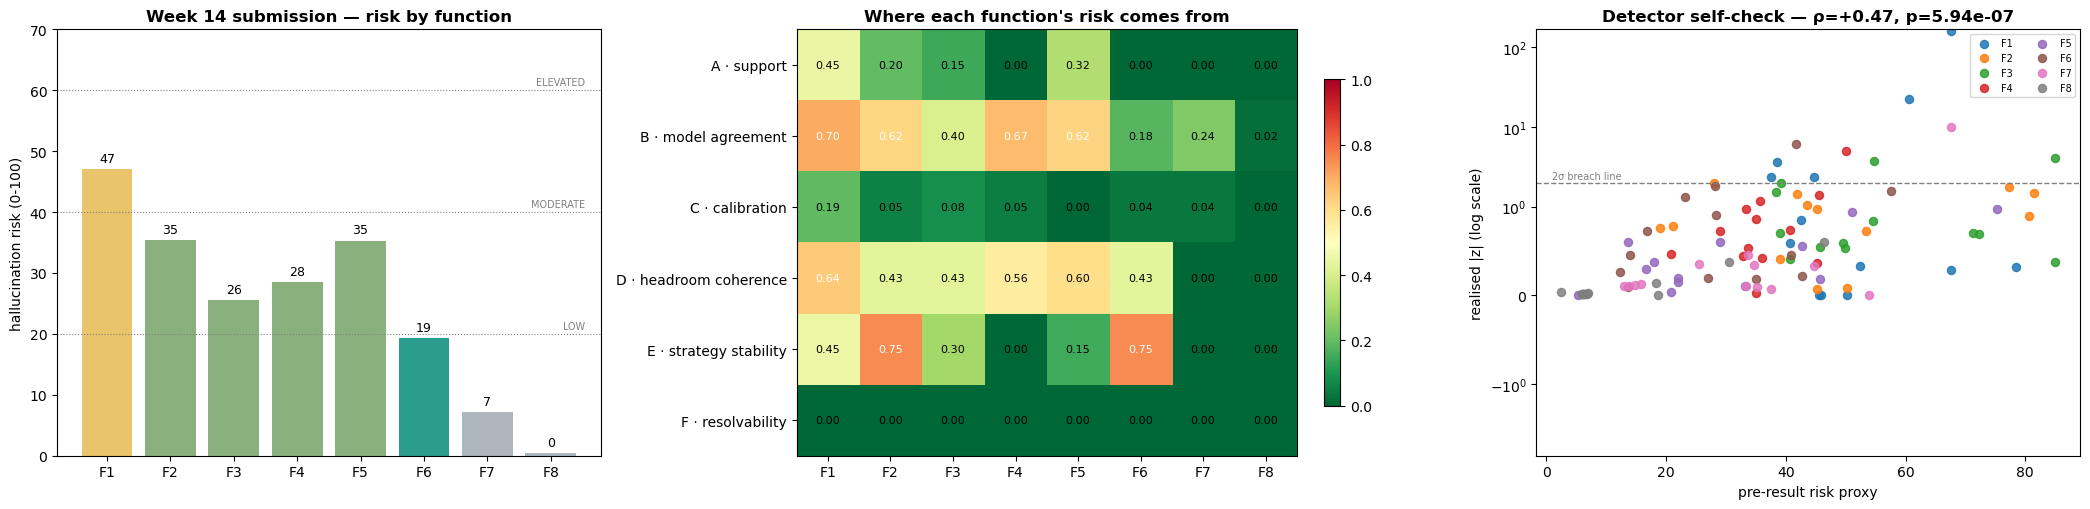

In [12]:
import matplotlib.pyplot as plt

BANDCOL = {"LOW": "#2a9d8f", "MODERATE": "#8ab17d", "ELEVATED": "#e9c46a",
           "HIGH": "#f4a261", "SEVERE": "#e76f51", "LOCK": "#adb5bd"}
fig, axes = plt.subplots(1, 3, figsize=(21, 5.2))

ax = axes[0]
fs = [f"F{f}" for f in FIDS]
sc = [RES[f]["score"] for f in FIDS]
ax.bar(fs, sc, color=[BANDCOL[RES[f]["verdict"]] for f in FIDS])
for i, v in enumerate(sc):
    ax.text(i, v + 1.2, f"{v:.0f}", ha="center", fontsize=9)
for thr, lab in ((20, "LOW"), (40, "MODERATE"), (60, "ELEVATED")):
    ax.axhline(thr, color="gray", ls=":", lw=0.8)
    ax.text(len(fs) - 0.45, thr + 0.8, lab, fontsize=7, color="gray", ha="right")
ax.set_ylim(0, max(70, max(sc) + 12)); ax.set_ylabel("hallucination risk (0-100)")
ax.set_title(f"Week {TARGET_WEEK} submission — risk by function", fontweight="bold")

ax = axes[1]
keys = list(WEIGHTS)
M = np.array([[RES[f]["parts"][k] for f in FIDS] for k in keys])
im = ax.imshow(M, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(FIDS)), fs)
ax.set_yticks(range(len(keys)), [AXIS_TITLES[k] for k in keys])
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if M[i, j] > 0.6 else "black")
ax.set_title("Where each function's risk comes from", fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.03)

ax = axes[2]
if len(BT):
    for f in FIDS:
        b = BT[BT.F == f]
        ax.scatter(b.proxy_score, b.absz, label=f"F{f}", s=34, alpha=0.85)
    ax.axhline(NOISE_BREACH_Z, color="gray", ls="--", lw=1)
    ax.text(1, NOISE_BREACH_Z * 1.12, f"{NOISE_BREACH_Z:.0f}σ breach line", fontsize=7, color="gray")
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlabel("pre-result risk proxy"); ax.set_ylabel("realised |z| (log scale)")
    ttl = "Detector self-check"
    if RHO:
        ttl += f" — ρ={RHO[0]:+.2f}, p={RHO[1]:.3g}"
    ax.set_title(ttl, fontweight="bold")
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(f"hallucination_audit_week{TARGET_WEEK}.png", dpi=130, bbox_inches="tight")
plt.show()

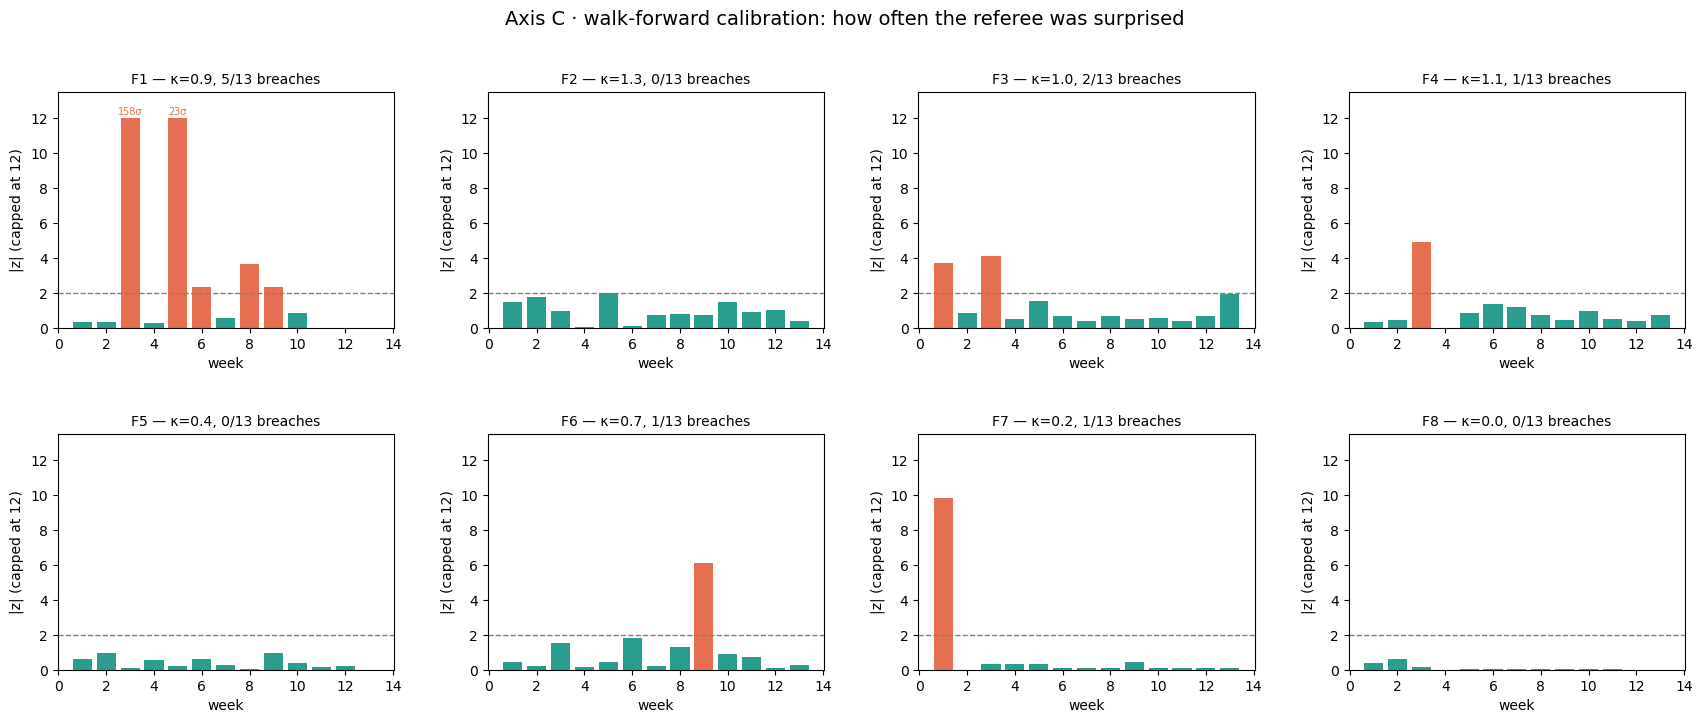

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(21, 7.5))
plt.subplots_adjust(hspace=0.45, wspace=0.28)
for f, ax in zip(FIDS, axes.ravel()):
    rec = RES[f]["C"].get("record")
    if rec is None or len(rec) == 0:
        ax.text(.5, .5, "no history", ha="center"); ax.set_title(f"F{f}"); continue
    cols = ["#e76f51" if b else "#2a9d8f" for b in rec.breach]
    ax.bar(rec.week, rec.absz.clip(upper=12), color=cols)
    ax.axhline(NOISE_BREACH_Z, color="gray", ls="--", lw=1)
    for w, z in zip(rec.week, rec.absz):
        if z > 12:
            ax.text(w, 12.2, f"{z:.0f}σ", ha="center", fontsize=7, color="#e76f51")
    k = RES[f]["C"]["kappa"]
    ax.set_title(f"F{f} — κ={k:.1f}, {int(rec.breach.sum())}/{len(rec)} breaches", fontsize=10)
    ax.set_xlabel("week"); ax.set_ylabel("|z| (capped at 12)"); ax.set_ylim(0, 13.5)
fig.suptitle("Axis C · walk-forward calibration: how often the referee was surprised",
             fontsize=14, y=0.99)
plt.savefig(f"hallucination_calibration_week{TARGET_WEEK}.png", dpi=130, bbox_inches="tight")
plt.show()

## 11 · Export

A CSV for the pipeline and a markdown report for the write-up. The report carries the critiques, not
just the scores, because the scores on their own are the least defensible part of this notebook.

In [14]:
SUMMARY.to_csv(f"hallucination_audit_week{TARGET_WEEK}.csv", index=False)

lines = [f"# Anti-hallucination audit — week {TARGET_WEEK}", "",
         f"Submission: `{os.path.basename(SUB_PATH)}`  ·  observations through week {N_WEEKS}",
         f"Engine baseline: {EMSG}", ""]
if RHO:
    lines += [f"Detector self-check: Spearman ρ = {RHO[0]:+.3f} (p = {RHO[1]:.3g}, n = {len(BT)}) "
              f"between the pre-result risk proxy and realised surprise.", ""]
lines += ["## Summary", "", SUMMARY.drop(columns=["query"]).to_markdown(index=False), "",
          "## Per-function critique", ""]
for f in FIDS:
    lines += ["```", critique(RES[f]), "```", ""]
lines += ["## Standing caveats", "",
          "- The risk score is a weighted judgement call, not a fitted quantity; `WEIGHTS` is exposed "
          "so it can be argued with.",
          "- Axis C rests on nine walk-forward weeks per function.",
          "- Axis G reports `UNVERIFIABLE` for every claim shape it was not taught; that is *unchecked*, "
          "not clean.",
          "- Pathology labels are inherited from 05b, so 05b's misclassifications propagate here.",
          "- A high score is a request for a second look, not a veto."]
# encoding is explicit because the report contains rho, kappa and sigma; the Windows
# default codec (cp1252) cannot represent them.
open(f"hallucination_audit_week{TARGET_WEEK}.md", "w", encoding="utf-8").write("\n".join(lines))
print(f"Wrote: hallucination_audit_week{TARGET_WEEK}.csv, hallucination_audit_week{TARGET_WEEK}.md,")
print(f"       hallucination_audit_week{TARGET_WEEK}.png, hallucination_calibration_week{TARGET_WEEK}.png")

Wrote: hallucination_audit_week14.csv, hallucination_audit_week14.md,
       hallucination_audit_week14.png, hallucination_calibration_week14.png


## 12 · Turning on Axis G

Axis G stays dark until you give it prose. Paste the reasoning behind each pick — your own note, or an
LLM's recommendation — into `RATIONALES` at the top of the notebook and re-run:

```python
RATIONALES = {
    1: "The log-quadratic vertex sits just past the incumbent; we expect y ≈ 1.85. "
       "Best-ever is 1.524636 and the fit is monotone increasing in x1.",
    5: "F5 is solved — no headroom left on this function.",
}
```

Each sentence comes back `SUPPORTED`, `CONTRADICTED`, or `UNVERIFIABLE` with the evidence beside it.
On the example above, the third sentence would be contradicted: F5's independent ceiling proxy still
leaves headroom, and the campaign has already watched a "solved" F5 nearly double in week 9.

To inspect a single function's claim table directly:

```python
display(RES[1]["G"]["table"])
```

## Extending it

- **`WEIGHTS`** — the axis weights. If you think calibration should dominate on this board, say so here.
- **`NOISE_BREACH_Z`** — what counts as a breach in the walk-forward check.
- **`LOCK_PRIOR`** — keep in step with 05b and 07, or F7/F8 will be audited as if they were still open.
- **New axes** — anything returning a 0–1 score slots into `WEIGHTS` and `audit_function` without
  touching the rest.

## The standing caveat

Every number here is produced by models of the same family as the ones being audited. The check
narrows the failure mode; it does not close it. Where the audit and your own reading of the board
disagree, the disagreement is the finding — write it down and let next week's result settle it.